In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


In [2]:
df = pd.read_csv(r"C:\Users\ayush\Downloads\car_prediction_datasett.csv")
print("Shape:", df.shape)
df.head()


Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
df.describe(include="all")

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,301,301.000000,301.000000,301.000000,301.000000,301,301,301,301.000000
unique,98,NaN,NaN,NaN,NaN,3,2,2,NaN
top,city,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,26,NaN,NaN,NaN,NaN,239,195,261,NaN
mean,NaN,2013.627907,4.661296,7.628472,36947.205980,NaN,NaN,NaN,0.043189
std,NaN,2.891554,5.082812,8.644115,38886.883882,NaN,NaN,NaN,0.247915
min,NaN,2003.000000,0.100000,0.320000,500.000000,NaN,NaN,NaN,0.000000
25%,NaN,2012.000000,0.900000,1.200000,15000.000000,NaN,NaN,NaN,0.000000
50%,NaN,2014.000000,3.600000,6.400000,32000.000000,NaN,NaN,NaN,0.000000
75%,NaN,2016.000000,6.000000,9.900000,48767.000000,NaN,NaN,NaN,0.000000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [6]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Duplicate rows found: 2
Shape after dropping duplicates: (299, 9)


In [7]:
cat_cols = ["Car_Name", "Fuel_Type", "Seller_Type", "Transmission"]

for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().str.lower()

for c in ["Fuel_Type", "Seller_Type", "Transmission"]:
    print(c, "->", sorted(df[c].unique()))


Fuel_Type -> ['cng', 'diesel', 'petrol']
Seller_Type -> ['dealer', 'individual']
Transmission -> ['automatic', 'manual']


In [8]:
CURRENT_YEAR = 2026

print("Year range:", df["Year"].min(), "-", df["Year"].max())
print("Any future years?", (df["Year"] > CURRENT_YEAR).sum())
print("Any negative Kms_Driven?", (df["Kms_Driven"] < 0).sum())
print("Any negative prices?", ((df["Selling_Price"] < 0) | (df["Present_Price"] < 0)).sum())

df = df[(df["Year"] <= CURRENT_YEAR) & (df["Kms_Driven"] >= 0) &
        (df["Selling_Price"] >= 0) & (df["Present_Price"] >= 0)].reset_index(drop=True)
df.shape

Year range: 2003 - 2018
Any future years? 0
Any negative Kms_Driven? 0
Any negative prices? 0


(299, 9)

In [9]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [10]:
df["Car_Age"] = CURRENT_YEAR - df["Year"]
df["Brand"] = df["Car_Name"].str.split().str[0]

print("Number of unique brands/models extracted:", df["Brand"].nunique())
df[["Car_Name", "Year", "Car_Age", "Brand"]].head(10)

Number of unique brands/models extracted: 44


,Car_Name,Year,Car_Age,Brand
0,ritz,2014,12,ritz
1,sx4,2013,13,sx4
2,ciaz,2017,9,ciaz
3,wagon r,2011,15,wagon
4,swift,2014,12,swift
5,vitara brezza,2018,8,vitara
6,ciaz,2015,11,ciaz
7,s cross,2015,11,s
8,ciaz,2016,10,ciaz
9,ciaz,2015,11,ciaz


In [11]:
brand_counts = df["Brand"].value_counts()
rare_brands = brand_counts[brand_counts <= 2].index
df["Brand"] = df["Brand"].apply(lambda b: "other" if b in rare_brands else b)

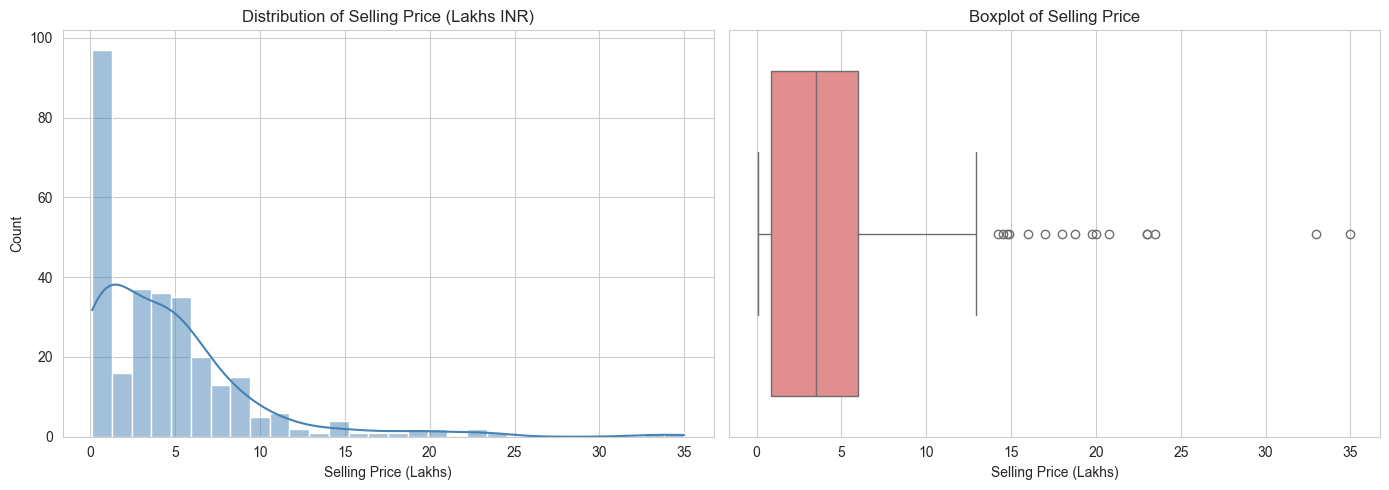

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Selling_Price"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Selling Price (Lakhs INR)")
axes[0].set_xlabel("Selling Price (Lakhs)")

sns.boxplot(x=df["Selling_Price"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot of Selling Price")
axes[1].set_xlabel("Selling Price (Lakhs)")

plt.tight_layout()
plt.show()

C:\Users\ayush\AppData\Local\Temp\ipykernel_23836\1183491393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", palette="Set2")


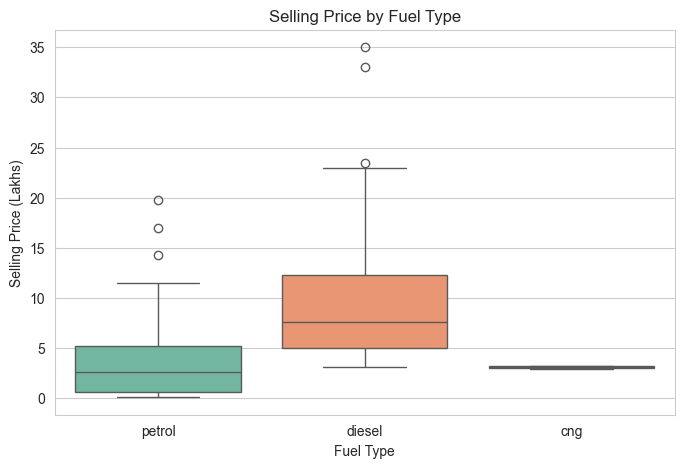

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", palette="Set2")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs)")
plt.show()

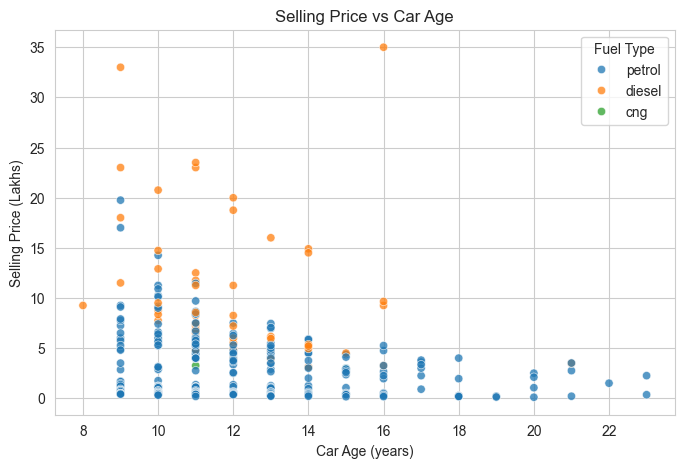

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Car_Age", y="Selling_Price", hue="Fuel_Type", alpha=0.75)
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price (Lakhs)")
plt.legend(title="Fuel Type")
plt.show()


C:\Users\ayush\AppData\Local\Temp\ipykernel_23836\1633977065.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Transmission", y="Selling_Price", ax=axes[0], palette="Set3")


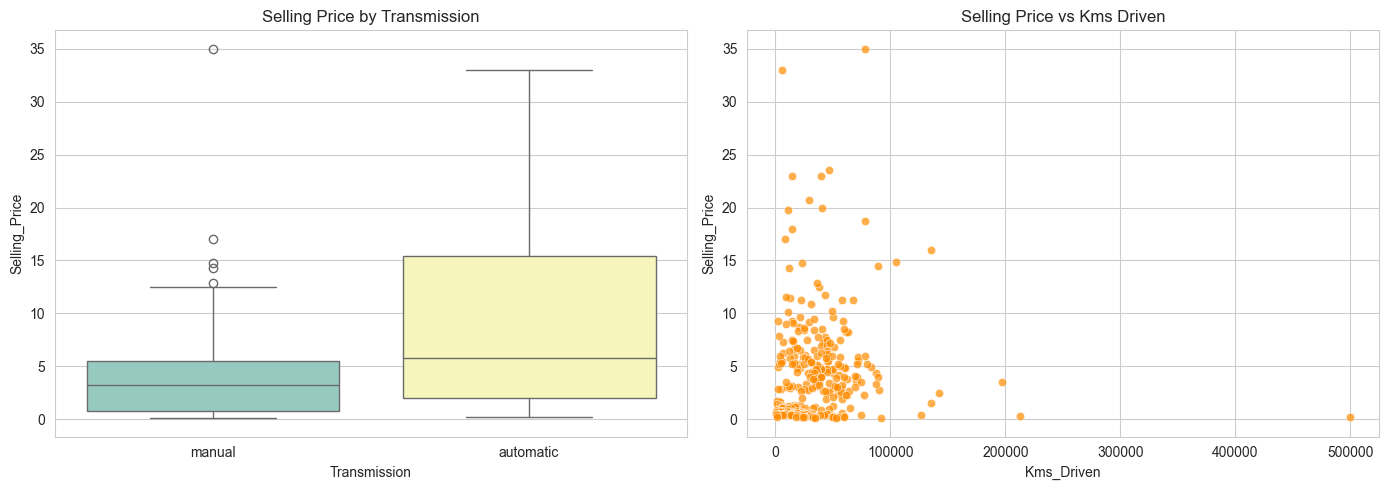

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Transmission", y="Selling_Price", ax=axes[0], palette="Set3")
axes[0].set_title("Selling Price by Transmission")

sns.scatterplot(data=df, x="Kms_Driven", y="Selling_Price", ax=axes[1], alpha=0.7, color="darkorange")
axes[1].set_title("Selling Price vs Kms Driven")

plt.tight_layout()
plt.show()


In [16]:
model_df = df.drop(columns=["Car_Name", "Year"])

encoded_df = pd.get_dummies(
    model_df,
    columns=["Fuel_Type", "Seller_Type", "Transmission", "Brand"],
    drop_first=True
)

print("Shape after encoding:", encoded_df.shape)
encoded_df.head()

Shape after encoding: (299, 40)


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_diesel,Fuel_Type_petrol,Seller_Type_individual,Transmission_manual,Brand_alto,...,Brand_other,Brand_ritz,Brand_royal,Brand_swift,Brand_sx4,Brand_tvs,Brand_verna,Brand_wagon,Brand_xcent,Brand_yamaha
0,3.35,5.59,27000,0,12,False,True,False,True,False,...,False,True,False,False,False,False,False,False,False,False
1,4.75,9.54,43000,0,13,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,7.25,9.85,6900,0,9,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.85,4.15,5200,0,15,False,True,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,4.60,6.87,42450,0,12,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False


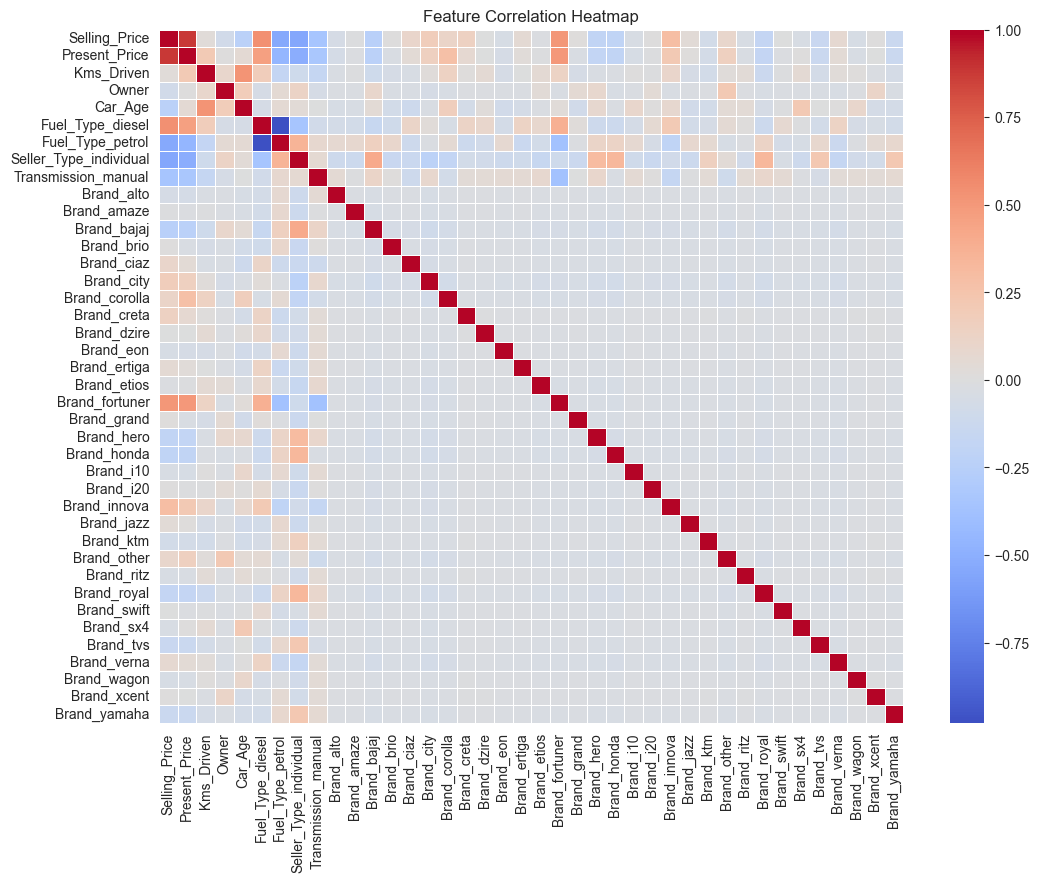

In [17]:
plt.figure(figsize=(12, 9))
corr = encoded_df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.4)
plt.title("Feature Correlation Heatmap")
plt.show()


In [18]:
corr["Selling_Price"].drop("Selling_Price").sort_values(ascending=False)

Present_Price             0.876378
Fuel_Type_diesel          0.543541
Brand_fortuner            0.510822
Brand_innova              0.289892
Brand_city                0.175493
Brand_creta               0.145882
Brand_corolla             0.111476
Brand_ciaz                0.102055
Brand_other               0.092250
Brand_verna               0.067625
Brand_ertiga              0.052164
Brand_jazz                0.038551
Kms_Driven                0.028566
Brand_grand               0.011800
Brand_xcent               0.007628
Brand_i20                 0.006268
Brand_brio                0.005808
Brand_swift              -0.001301
Brand_dzire              -0.002683
Brand_amaze              -0.011457
Brand_etios              -0.015125
Brand_i10                -0.040089
Brand_ritz               -0.040418
Brand_sx4                -0.041162
Brand_eon                -0.048592
Brand_wagon              -0.048608
Brand_alto               -0.056740
Brand_ktm                -0.076105
Owner               

In [19]:
X = encoded_df.drop(columns=["Selling_Price"])
y = encoded_df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (239, 39)
Test shape: (60, 39)


In [20]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Linear Regression
Trained: Random Forest
Trained: Gradient Boosting


In [21]:
results = []

for name, model in trained_models.items():
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,1.365793,2.502792,0.756959
1,Gradient Boosting,1.238589,3.026657,0.644568
2,Random Forest,1.453531,3.693789,0.470611


C:\Users\ayush\AppData\Local\Temp\ipykernel_23836\2925222853.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2", palette="viridis")


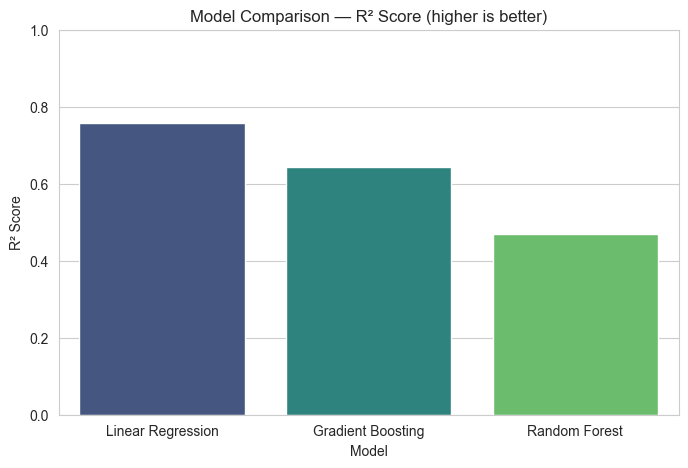

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="R2", palette="viridis")
plt.title("Model Comparison — R² Score (higher is better)")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.show()

In [23]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best performing model: {best_model_name}")
print(results_df.iloc[0])

Best performing model: Linear Regression
Model    Linear Regression
MAE               1.365793
RMSE              2.502792
R2                0.756959
Name: 0, dtype: object


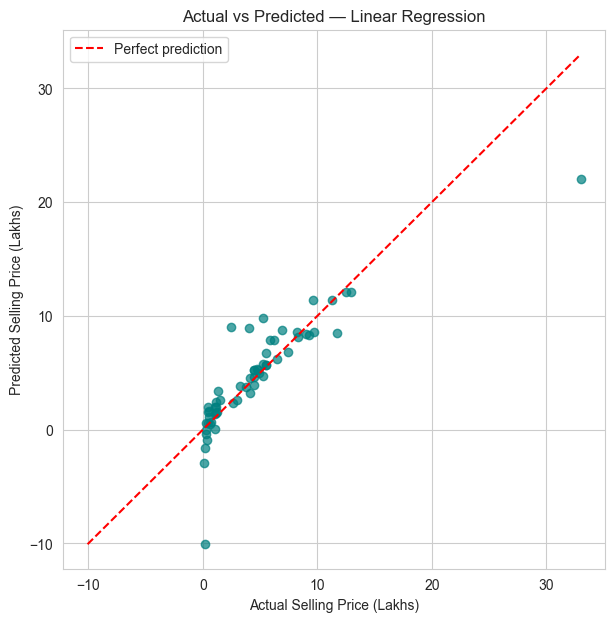

In [24]:
preds_best = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds_best, alpha=0.7, color="teal")
lims = [min(y_test.min(), preds_best.min()), max(y_test.max(), preds_best.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Selling Price (Lakhs)")
plt.ylabel("Predicted Selling Price (Lakhs)")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.legend()
plt.show()

C:\Users\ayush\AppData\Local\Temp\ipykernel_23836\1369239163.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances.values, y=top_importances.index, palette="mako")


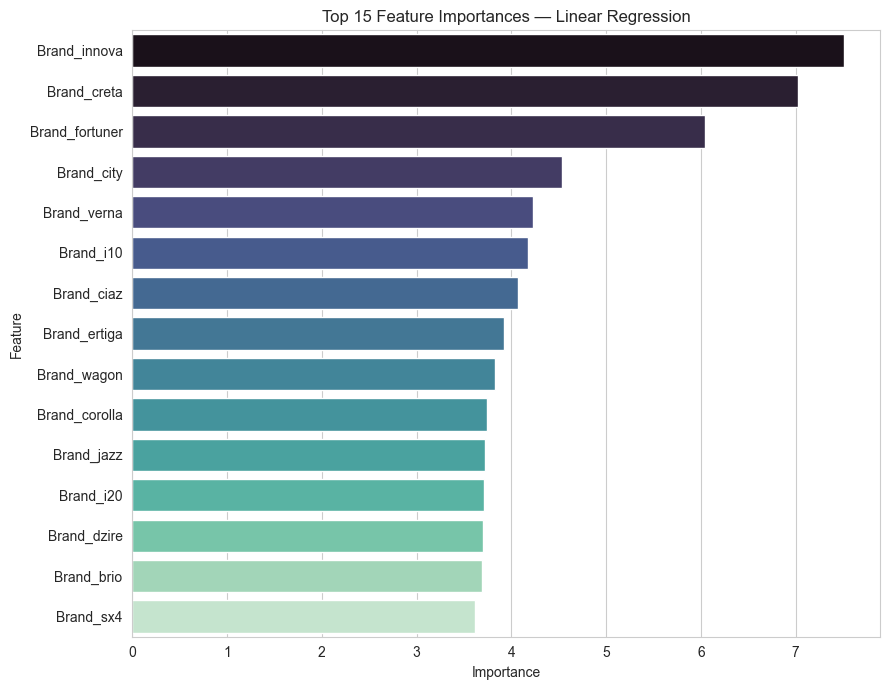

In [25]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_), index=X.columns)

top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_importances.values, y=top_importances.index, palette="mako")
plt.title(f"Top 15 Feature Importances — {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()